# Create environment

In [1]:
from gymnasium.core import ObsType
from typing import Literal, Any, SupportsFloat
from ppafm.io import loadXYZ
from ppafm.ocl.AFMulator import AFMulator
from ppafm.ocl.oclUtils import init_env
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import argrelextrema
import numpy as np
from collections import defaultdict
import gymnasium as gym

class AfmEnvironment(gym.Env):
    metadata = {'render.modes': ['human', 'rgb_array']}
    
    def _compute_imgs(self, surface_path: str, params_path: str, i_platform: int = 0) -> tuple[AFMulator, np.ndarray]:
        """
        Generates AFM images with ppafm
        
        Parameters
        ----------
        surface_path : str
            Path to a .xyz file containing the surface
        params_path : str
            Path to a .ini file containing the parameters for the simulation
        i_platform : int
            Index of OpenCL device

        Returns
        -------
        AFMulator
            AFMulator object used to generate images
        np.ndarray
            Generated images. The second and third axis are already reversed.
        """
        init_env(i_platform=i_platform)
        xyzs, Zs, qs, _ = loadXYZ(surface_path)
        afmulator = AFMulator.from_params(params_path)
        afm_images = afmulator(xyzs, Zs, qs)
        
        return afmulator, afm_images[:,::-1,::-1]

    # TODO: Implement render mode
    # TODO: Figure out how to handle multiple surfaces at once
    def __init__(self,
            surface_path: str,
            params_path: str,
            i_platform: int = 0,
            sigma: int = 4,
            num_historic_data: int = 4,
            render_mode: Literal[None, 'human', 'rgb'] = None
        ) -> None:
        """
        Constructor
        
        Parameters
        ----------
        surface_path : str
            Path to a .xyz file containing the surface
        params_path : str
            Path to a .ini file containing the parameters for the simulation
        i_platform : int
            Index of OpenCL device
        render_mode : Literal[None, 'human', 'rgb']
            Render mode to use
        """
        super().__init__()

        self.num_historic_data = num_historic_data

        # Generate images
        self.afmulator, self.afm_images = self._compute_imgs(surface_path, params_path, i_platform)
        
        # Calculate heights for each slice
        self.z_height_map = np.linspace(
            self.afmulator.scan_window[0][2],
            self.afmulator.scan_window[1][2] - self.afmulator.df_steps * self.afmulator.dz,
            self.afmulator.scan_dim[2] - self.afmulator.df_steps + 1,
        )
        
        # Get all minima in the z direction and only keep the highest one
        minima = np.array(argrelextrema(self.afm_images, np.less_equal, axis=2)).T
        minima_dict = defaultdict(list)
        for xx, yy, zz in minima:
            minima_dict[xx, yy].append(zz)
            minima_dict[xx, yy] = [max(minima_dict[xx, yy])]
        
        argmin_image = np.zeros(self.afm_images.shape[0:-1], dtype=int)
        for pixel, val in minima_dict.items():
            argmin_image[pixel] = int(val[0])
        
        # Convert index to actual height and smooth optimal surface
        self.min_image = self.z_height_map[argmin_image]
        # TODO: Shift optimal height upwards?
        self.optimal_height = gaussian_filter(self.min_image, sigma=sigma)
        
        # Define observation space
        x_px_max, y_px_max, _ = self.afm_images.shape
        self.z_min = self.afmulator.scan_window[0][2]
        self.z_max = self.afmulator.scan_window[1][2] - self.afmulator.df_steps * self.afmulator.dz
        self.observation_space = gym.spaces.Dict(
            {
                "x": gym.spaces.Box(0, x_px_max - 1, shape=(num_historic_data,), dtype=np.int64),
                "y": gym.spaces.Box(0, y_px_max - 1, shape=(num_historic_data,), dtype=np.int64),
                "dz": gym.spaces.Box(-self.z_max, self.z_max, shape=(num_historic_data,), dtype=np.float64),
                "df": gym.spaces.Box(-np.inf, np.inf, shape=(num_historic_data,), dtype=np.float64),
            }
        )
        
        # Define action space
        # TODO: What is the maximum speed for the tip?
        self.action_space = gym.spaces.Box(-1, 1, shape=(1,), dtype=np.float64)

        self.reset()

    def _get_closest_slice_index(self, z: float) -> np.int64:
        """
        Returns the index of the slice closest to a given z height

        Parameters
        ----------
        z : float
            Height of the desired slice

        Returns
        -------
        int : index of the closest slice
        """
        return np.abs(self.z_height_map - z).argmin()

    def _get_two_closest_z_planes(self, z):
        """
        Returns the indices of the two closest values in array to the given value.

        Parameters
        ----------
        value : float
            The target value

        Returns
        -------
        tuple : (int, int)
            Indices of the two closest values in ascending order
        """
        return np.sort(np.argsort(np.abs(self.z_height_map - z))[0:2])


    def _get_interpolated_df(self, x: int, y: int, z: float):
        """
        Interpolates a value at the given xy coordinates
        for a specific height `z` using two closest z-planes.

        Parameters
        ----------
        x : int
            The x index
        y : int
            The y index
        z : float
            The z position at which the value needs to be interpolated.

        Returns
        -------
        float
            The interpolated value at the specified z-coordinate.
        """
        z1, z2 = self._get_two_closest_z_planes(z)
        k = (self.afm_images[x, y, z2] - self.afm_images[x, y, z1]) / (self.z_height_map[z2] - self.z_height_map[z1])
        return k * (z - self.z_height_map[z1]) + self.afm_images[x, y, z1]


    def _get_obs(self):
        """
        Convert internal state to observation format.

        Returns
        -------
        dict
            Observation dictionary with x and y position, difference to the starting height and change in frequency
        """
        return {
            "x": self._x,
            "y": self._y,
            "dz": self._dz,
            "df": self._df
        }

    def _get_info(self):
        """
        Compute auxiliary information for debugging.

        Returns
        -------
            dict : z height and corresponding index
        """
        return {
            "z": self.z_start,
            "z_i": self.z_start_index,
            "generated_image": self.generated_image,
        }

    # TODO: Randomize start position and rotation. Maybe also switch between different surfaces?
    def reset(self, seed: int | None = None, options : dict[str, Any] | None = None) -> tuple[ObsType, dict[str, Any]]:
        """
        Resets the environment
        
        Parameters
        ----------
        seed : int | None
            Seed for the random number generator
        options : dict[str, Any] | None
            Options for super class

        Returns
        -------

        """
        super().reset(seed=seed, options=options)

        if seed is not None:
            np.random.seed(seed)

        self.terminated = False

        z = self.z_max - np.random.rand()
        self.z_start_index = self._get_closest_slice_index(z)
        self.z_start = self.z_height_map[self.z_start_index]

        self._x = np.zeros(self.num_historic_data, dtype=np.int64)
        self._y = np.zeros(self.num_historic_data, dtype=np.int64)
        self._dz = np.zeros(self.num_historic_data)
        self._df = self.afm_images[0, 0, self.z_start_index] * np.ones(self.num_historic_data)

        self.generated_image = np.empty(self.afm_images.shape[:2])
        self.generated_image[:] = np.nan
        self.generated_image[0, 0] = self._get_interpolated_df(0, 0, self.z_start)

        return self._get_obs(), self._get_info()

    def _insert_into_array(self, array : np.ndarray, data_point):
        """
        Modifies an array by rolling it to the right and inserting a new data point at the beginning.

        Parameters
        ----------
        array : numpy.ndarray
            The input array to be modified.
        data_point : Any
            The new data point

        Returns
        -------
        numpy.ndarray
            The modified array
        """
        array = np.roll(array, 1)
        array[0] = data_point
        return array
        
    def step(self, action) -> tuple[ObsType, SupportsFloat, bool, bool, dict[str, Any]]:
        """Execute one timestep within the environment.

        Args:
            action: The distance in Ångström that the tip should move.

        Returns:
            tuple: (observation, reward, terminated, truncated, info)
        """
        if self.terminated:
            return self._get_obs(), 0, True, False, self._get_info()

        x_px_max, y_px_max, _ = self.afm_images.shape
        x_current, y_current = int(self._x[0]), int(self._y[0])

        # Determine new position based on raster scan pattern
        if y_current % 2 == 0:  # Even rows: moving right
            if x_current + 1 >= x_px_max:
                # End of row reached, move to next row
                self._x = self._insert_into_array(self._x, x_current)
                self._y = self._insert_into_array(self._y, y_current + 1)
            else:
                # Move right
                self._x = self._insert_into_array(self._x, x_current + 1)
                self._y = self._insert_into_array(self._y, y_current)
        else:  # Odd rows: moving left
            if x_current - 1 < 0:
                # Beginning of row reached, move to next row
                self._x = self._insert_into_array(self._x, x_current)
                self._y = self._insert_into_array(self._y, y_current + 1)
            else:
                # Move left
                self._x = self._insert_into_array(self._x, x_current - 1)
                self._y = self._insert_into_array(self._y, y_current)

        x_new, y_new = int(self._x[0]), int(self._y[0])

        # Update dz and df
        # TODO: Clip z
        dz_new = self._dz[0] + action[0]
        self._dz = self._insert_into_array(self._dz, dz_new)
        z_new = self.z_start + dz_new
        self._df = self._insert_into_array(self._df, self._get_interpolated_df(x_new, y_new, z_new))
        self.generated_image[x_new, y_new] = self._df[0]

        # Check for crashes
        # TODO: Add tolerance?
        if z_new < self.min_image[x_new, y_new]:
            return self._get_obs(), -100, True, False, self._get_info()

        # TODO: Base reward should be set by variable
        reward = 10 - (z_new - self.optimal_height[x_new, y_new])

        if y_new % 2 == 0 and y_new == y_px_max - 1 and x_new == x_px_max - 1:
            self.terminated = True
        elif y_new % 2 == 1 and y_new == 0 and x_new == 0:
            self.terminated = True

        return self._get_obs(), reward, self.terminated, False, self._get_info()


 PACKAGE_PATH =  /home/henry/Documents/GDrive/DocumentsCloud/Uni/TU/InterdisciplinaryProject/repo/.venv/lib/python3.11/site-packages/ppafm
 CPP_PATH     =  /home/henry/Documents/GDrive/DocumentsCloud/Uni/TU/InterdisciplinaryProject/repo/.venv/lib/python3.11/site-packages/ppafm/cpp


## Initialize test environment

In [2]:
env = AfmEnvironment("materials/pt_111_small_rows_missing.xyz", "materials/params_code.ini")

Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s


In [3]:
env.reset(seed=123)
print(env._get_obs())
print(env.z_start_index)
print(env.z_start)
gym.spaces.Box(-np.inf, np.inf, shape=(1,), dtype=np.float64).sample()[0]

{'x': array([0, 0, 0, 0]), 'y': array([0, 0, 0, 0]), 'dz': array([0., 0., 0., 0.]), 'df': array([-0.0566851, -0.0566851, -0.0566851, -0.0566851])}
730
21.3


np.float64(1.2217060215931455)

## Automatic checker. Will fail, because of flawed internal logic.

In [6]:
from gymnasium.utils.env_checker import check_env

# Because there are nan values in the generated image, the env checker will fail.
try:
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print(f"Environment has issues: {e}")

Environment has issues: Deterministic step info are not equivalent for the same seed and action


In [7]:
observation = env._get_obs()
print(observation["x"] in gym.spaces.Box(0, 200, shape=(4,), dtype=np.int64))
print(observation["y"] in gym.spaces.Box(0, 200, shape=(4,), dtype=np.int64))
print(observation["dz"] in gym.spaces.Box(-22., 22., shape=(4,), dtype=np.float64))
print(observation["df"] in gym.spaces.Box(-np.inf, np.inf, shape=(4,), dtype=np.float64))

True
True
True
True


## Manually test environment

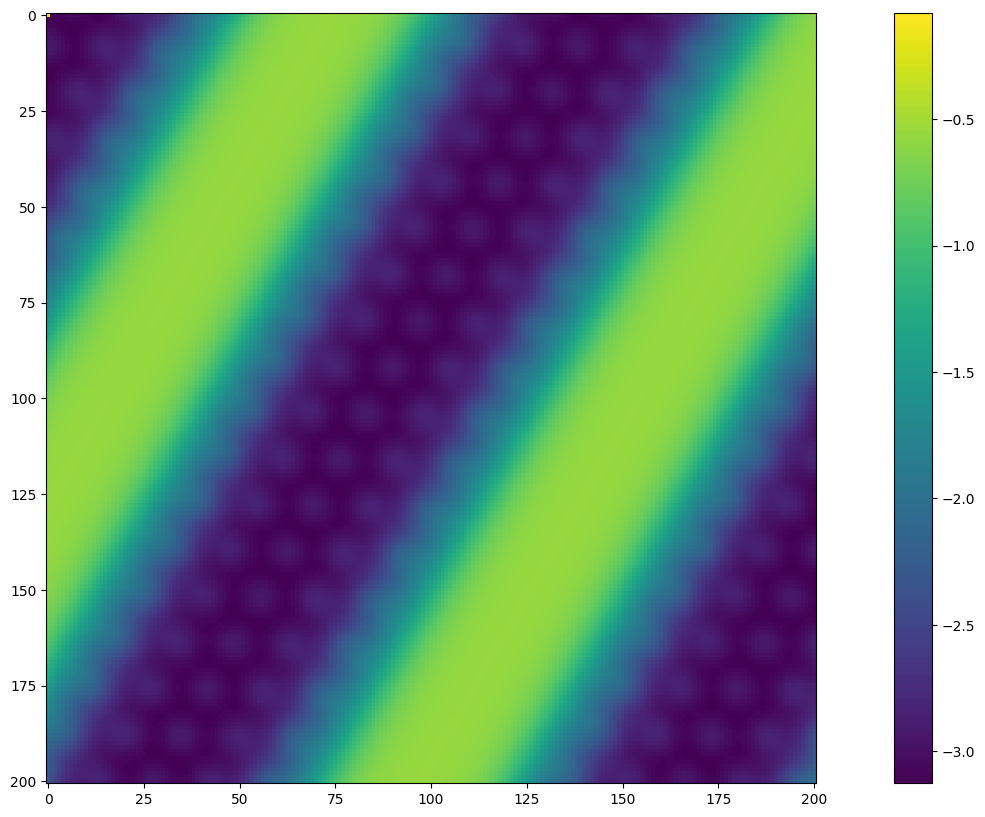

In [31]:
# Manually test environment. Reset, step to where we'll get a proper image and scan the same height
env.reset(123)
env.step([-5])

for i in range(201*201):
    env.step([0])

plt.imshow(env.generated_image.T)
plt.colorbar()

## Register environment

In [2]:
from gymnasium.envs.registration import register

register(
    id="gymnasium_env/AfmEnvironment-v0",
    # max_episode_steps=201*201,
    # reward_threshold=0.0,
    # kwargs={"surface_path": "materials/pt_111_small_rows_missing.xyz", "params_path": "materials/params_code.ini"},
    # nondeterministic=False,
    entry_point="gymnasium_env.envs:AfmEnvironment",
)


# Train simple agent

In [2]:
from stable_baselines3.common.callbacks import CheckpointCallback
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
import gymnasium as gym
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv
import os
import datetime
from torch.nn import ReLU

TRAIN_BASE_DIR = "train_results"
train_date = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
TRAIN_DIR = os.path.join(TRAIN_BASE_DIR, train_date)

def make_env(rank=0):
    def _init():
        env = AfmEnvironment(
            surface_path="materials/pt_111_small_5row_missing.xyz",
            params_path="materials/params_code.ini",
            num_historic_data=10,
        )
        env = Monitor(env)#, filename=os.path.join("./logs", f"env_{rank}"))
        return env
    return _init


env_arr = [make_env(i) for i in range(3)]
vec_env = DummyVecEnv(env_arr)

# env = make_env()

policy_kwargs = dict(
    # Sizes for the MLPs after the feature extractor
    net_arch=[dict(pi=[256, 128], vf=[256, 128])],
    activation_fn=ReLU,
)

model = PPO(
    "MultiInputPolicy",
    vec_env,
    verbose=1,
    tensorboard_log="./tensorboard_logs"
)

checkpoint_callback = CheckpointCallback(
    save_freq=10000,  # Save every 10,000 timesteps
    save_path=os.path.join(TRAIN_DIR, "models"),
    name_prefix="ppo_afm_model",
    save_replay_buffer=False,
)

model.learn(
    total_timesteps=10000000,
    progress_bar=True,
    tb_log_name="ppo_afm_env" + train_date,
    callback=checkpoint_callback,
)
model.save(os.path.join(TRAIN_DIR, "final_model"))


Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s
Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s
Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s
Using cuda device
Logging to ./tensorboard_logs/ppo_afm_env2025-10-27_16-11-52_1


Output()

----------------------------------
| rollout/           |           |
|    ep_len_mean     | 346       |
|    ep_rew_mean     | -2.05e+03 |
| time/              |           |
|    fps             | 2316      |
|    iterations      | 1         |
|    time_elapsed    | 2         |
|    total_timesteps | 6144      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 344          |
|    ep_rew_mean          | -2.42e+03    |
| time/                   |              |
|    fps                  | 1271         |
|    iterations           | 2            |
|    time_elapsed         | 9            |
|    total_timesteps      | 12288        |
| train/                  |              |
|    approx_kl            | 0.0034678604 |
|    clip_fraction        | 0.0279       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.42        |
|    explained_variance   | 0.00101      |
|    

In [2]:
from stable_baselines3 import PPO

env = AfmEnvironment("materials/pt_111_small_5row_missing.xyz", "materials/params_code.ini")
model = PPO.load("ppo_afm_env")

Initializing an OpenCL environment on NVIDIA CUDA
sigma:  0.7
Spherical harmonic: s
sigma:  0.7
Spherical harmonic: s


In [9]:
import pickle

EVAL_BASE_DIR = "eval_results"
start_and_finish = {}
episodes = []

for ep in range(500):
    print(ep)
    obs_arr, rewards_arr, info_arr, action_arr = [], [], [], []
    obs, info = env.reset()
    obs_arr.append(obs)
    info_arr.append(info)

    for i in range(201*201):
        action, _states = model.predict(obs)
        action_arr.append(action[0])
        obs, rewards, terminated, truncated, info = env.step(action)

        obs_arr.append(obs)
        rewards_arr.append(rewards)
        info_arr.append(info)

        if i%1000 == 0:
            print(" ", i)
        if terminated:
            break

    ep_dict = {
        "observations": obs_arr,
        "rewards": np.array(rewards_arr),
        "info": info_arr,
        "actions": np.array(action_arr),
        "episode_length": len(ep["observations"]),
        "terminated_early": len(ep["observations"]) < 201*201,
    }
    episodes.append(ep_dict)

EVAL_DIR = os.path.join(EVAL_BASE_DIR, datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S"))

with open(os.path.join(EVAL_DIR, "results.pkl"), "wb") as f:
    pickle.dump(episodes, f)
    model.save(os.path.join(EVAL_DIR, "model"))

0
  0
  1000
  2000
  3000
1
  0
  1000
  2000
2
  0
  1000
  2000
  3000
  4000
  5000
  6000
  7000
  8000
  9000
  10000
  11000
  12000
  13000
  14000
  15000
  16000
  17000
  18000
  19000
  20000
  21000
  22000
  23000
  24000
  25000
  26000
  27000
  28000
  29000
  30000
  31000
  32000
  33000
  34000
  35000
  36000
  37000
  38000
  39000
  40000
3
  0
  1000
  2000
  3000
  4000
  5000
  6000
  7000
  8000
  9000
  10000
  11000
  12000
  13000
  14000
  15000
  16000
  17000
  18000
  19000
  20000
  21000
  22000
  23000
  24000
  25000
  26000
  27000
  28000
  29000
  30000
  31000
  32000
  33000
  34000
  35000
  36000
  37000
  38000
  39000
  40000
4
  0
  1000
  2000
5
  0
  1000
  2000
  3000
6
  0
  1000
  2000
  3000
  4000
7
  0
  1000
  2000
  3000
  4000
8
  0
9
  0
  1000
  2000
  3000
10
  0
  1000
  2000
11
  0
  1000
  2000
  3000
  4000
12
  0
  1000
  2000
13
  0
  1000
  2000
14
  0
15
  0
  1000
  2000
16
  0
  1000
  2000
  3000
  4000
17
  0
  1

Average reward (full episode): -403.36417567564683
Average reward (early termination): 7.029062731869206


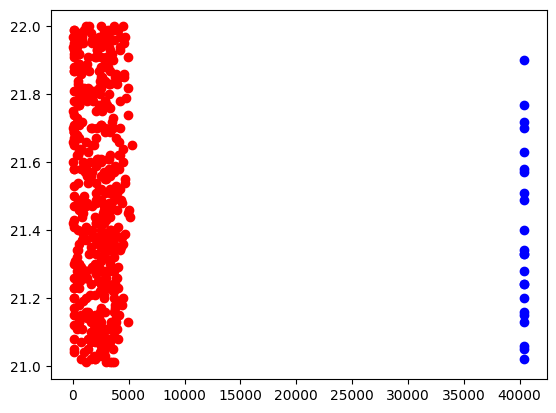

In [17]:
avg_reward_full = np.mean([np.mean(ep["rewards"]) for ep in episode if not ep["terminated_early"]])
avg_reward_early = np.mean([np.mean(ep["rewards"]) for ep in episode if ep["terminated_early"]])

print(f"Average reward (full episode): {avg_reward_full}")
print(f"Average reward (early termination): {avg_reward_early}")

for ep in episode:
    ep_len = len(ep["observations"])
    if ep_len < 201*201:
        plt.scatter(ep_len, ep["info"][0]["z:"], c="red")
    else:
        plt.scatter(ep_len, ep["info"][0]["z:"], c="blue")

plt.show()

In [59]:
def evaluate_run(episode, ma_action_len=100, ma_reward_len=100):
    info = episode["info"]
    observations = episode["observations"]
    actions = episode["actions"]
    rewards = episode["rewards"]

    plt.rcParams["figure.figsize"] = (12, 10)
    plt.imshow(info[-1]["generated_image"].T)
    plt.colorbar()
    plt.title("Captured image")
    plt.show()

    height_img = np.zeros(201 * 201)
    height_img[:] = np.nan
    for counter, o, i in zip(range(201*201), observations, info):
        height_img[counter] = i["z:"] + o["dz"][0]
    height_img = height_img.reshape((201, 201))
    height_img[1::2] = height_img[1::2, ::-1]
    plt.imshow(height_img)
    plt.title("Height of tip")
    plt.colorbar()
    plt.show()

    plt.rcParams["figure.figsize"] = (20, 10)
    moving_avg = np.convolve(np.array(actions).flatten(), np.ones(ma_action_len)/ma_action_len, mode='valid')
    plt.plot(moving_avg)
    plt.title("Moving average of actions")
    plt.show()

    plt.rcParams["figure.figsize"] = (20, 10)
    moving_avg = np.convolve(np.array(rewards).flatten(), np.ones(ma_reward_len)/ma_reward_len, mode='valid')
    plt.plot(moving_avg)
    plt.title(f"Moving average of rewards (AVG={np.mean(rewards):.2f}, STD={np.std(rewards):.2f}, TOTAL={np.sum(rewards):.2f})")
    plt.show()

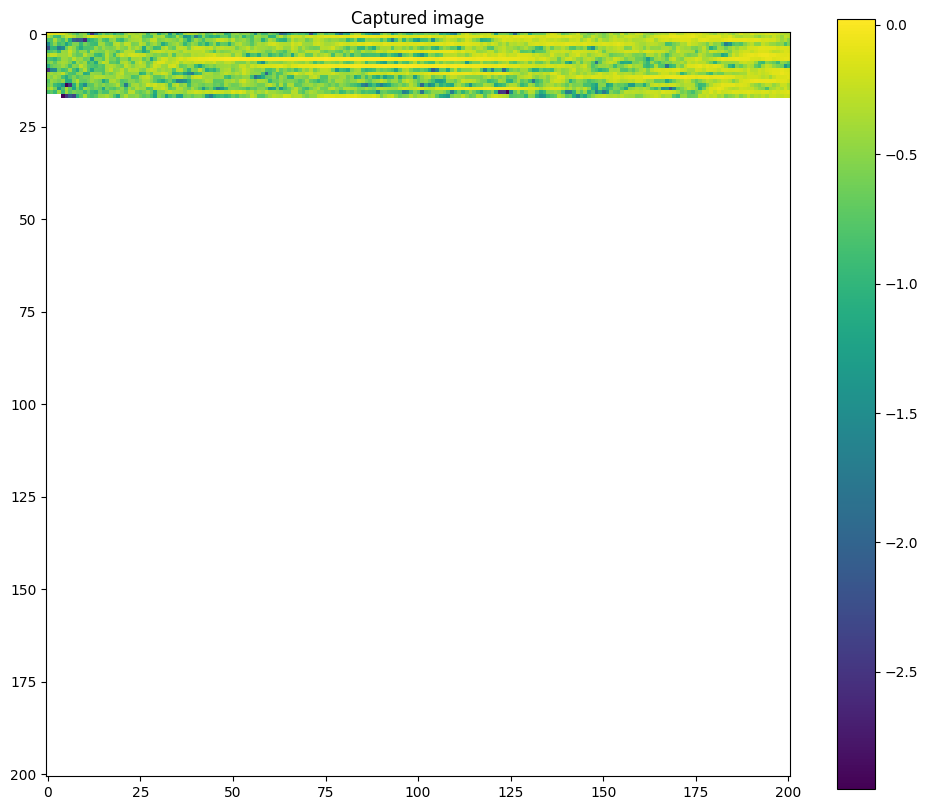

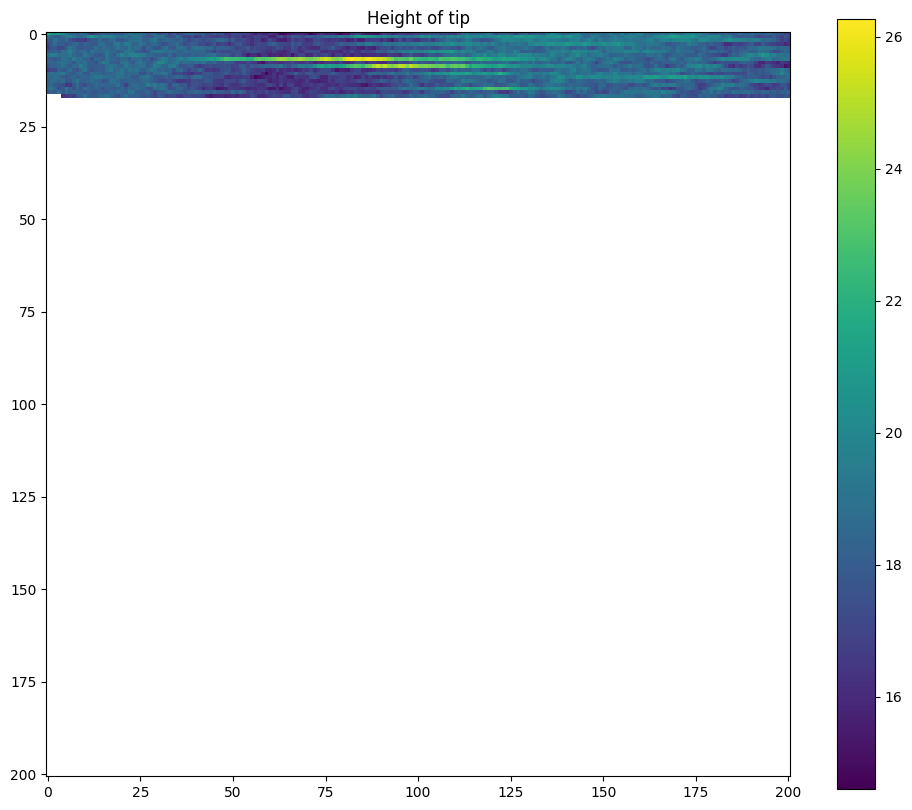

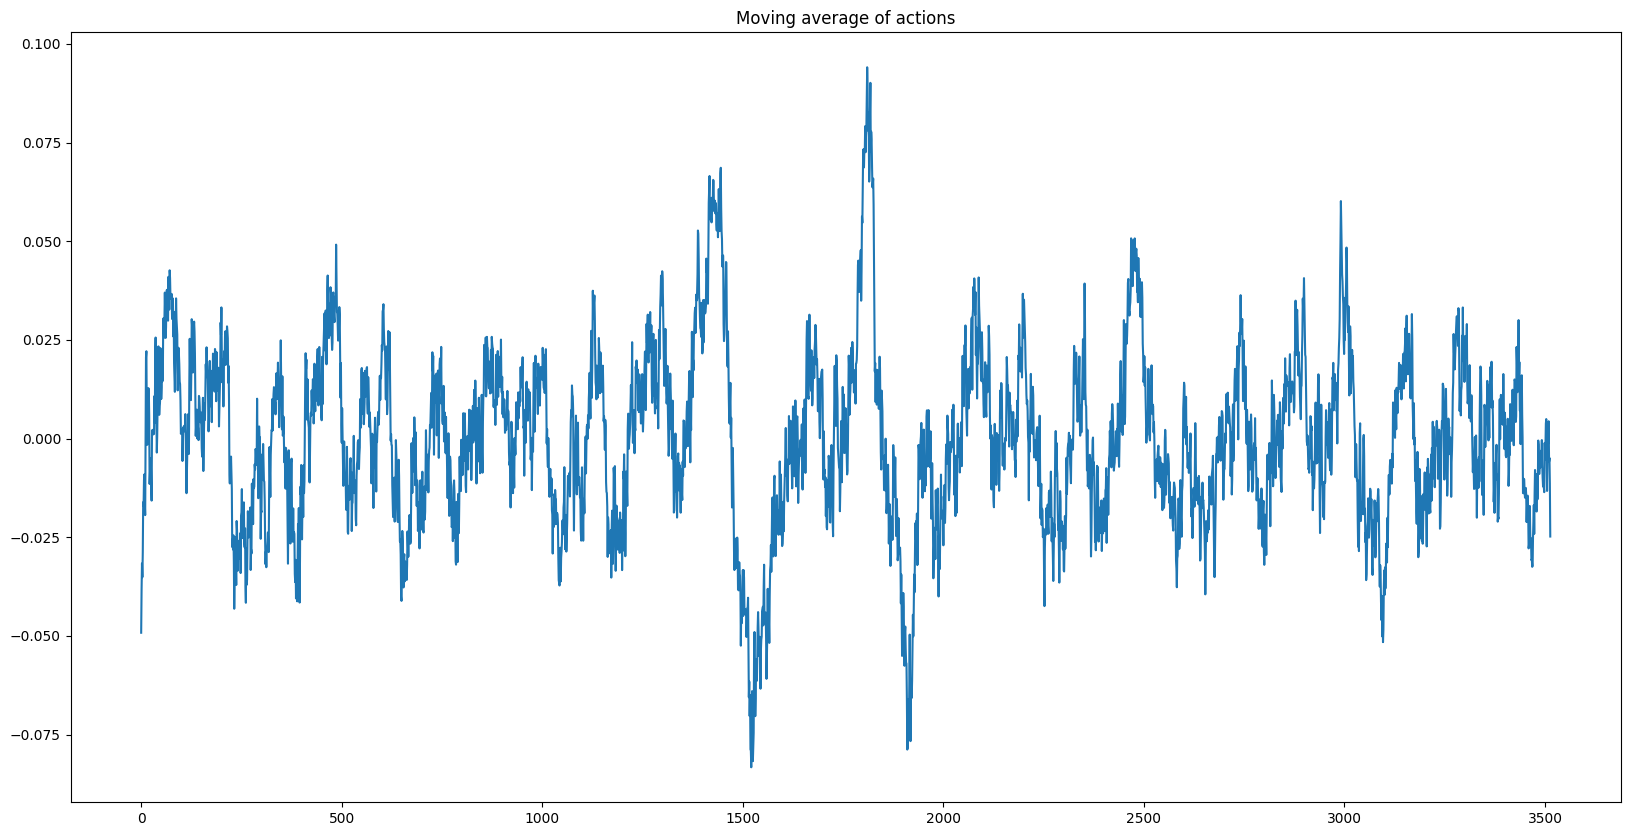

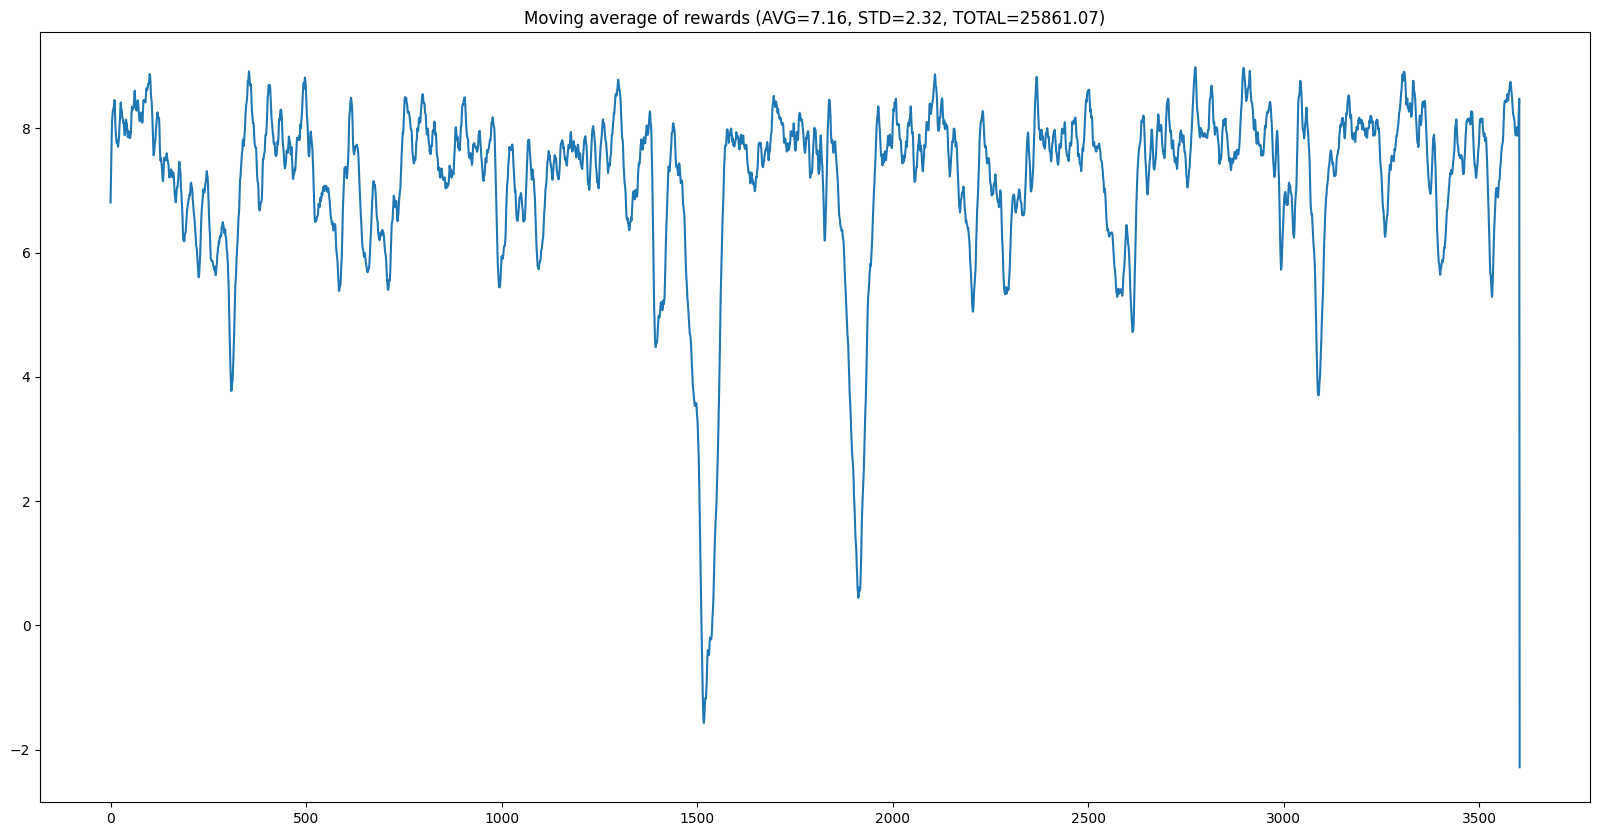

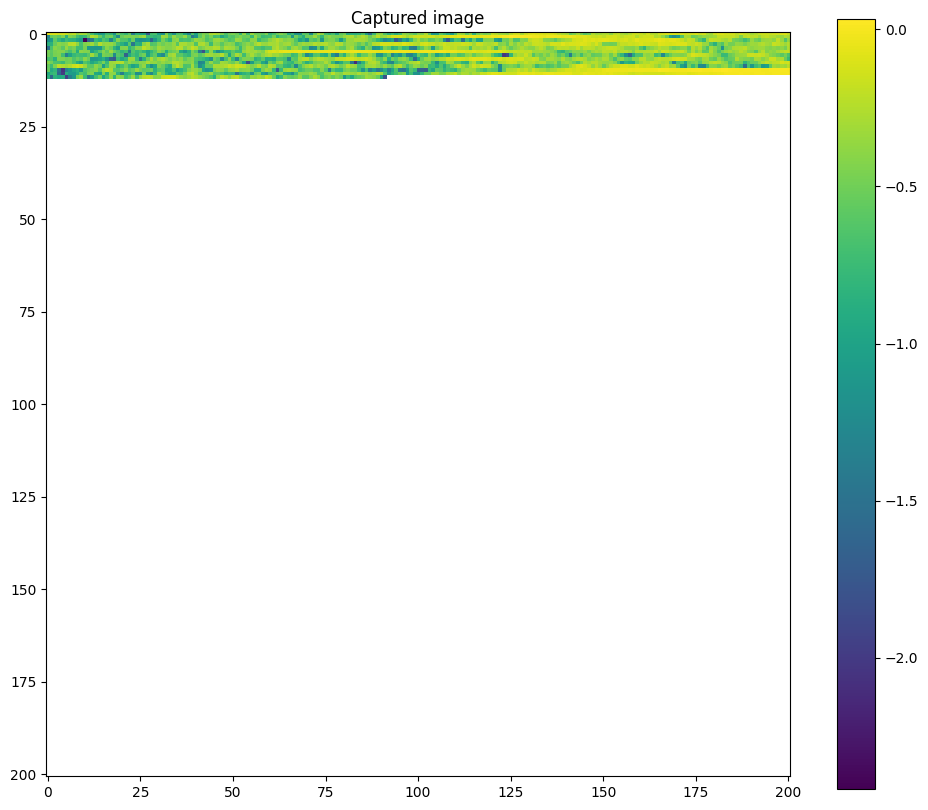

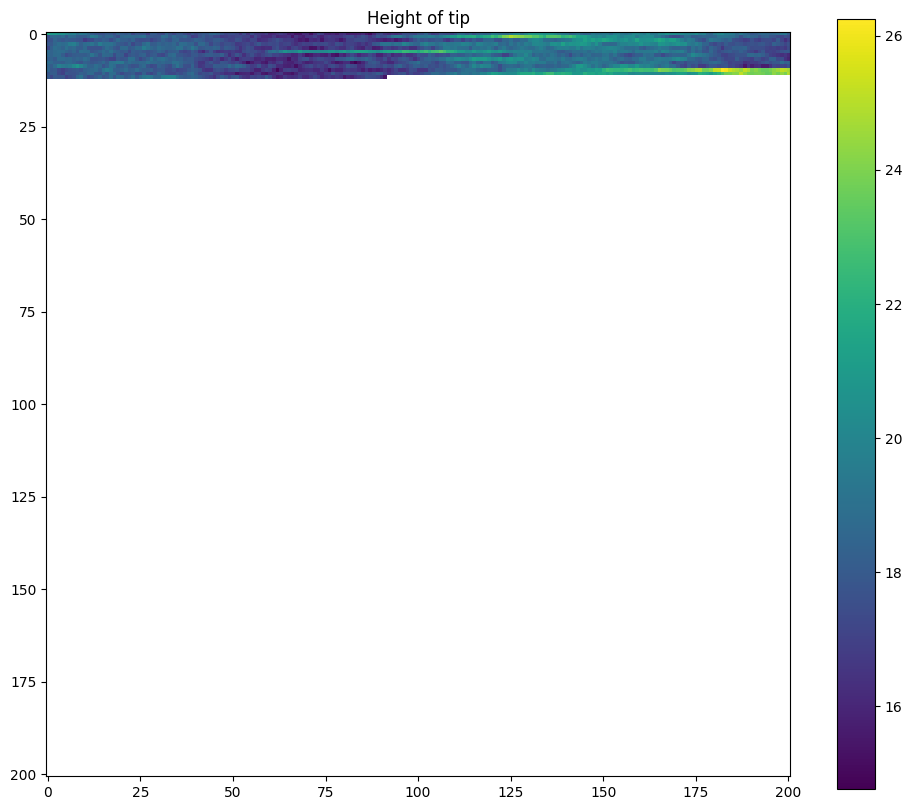

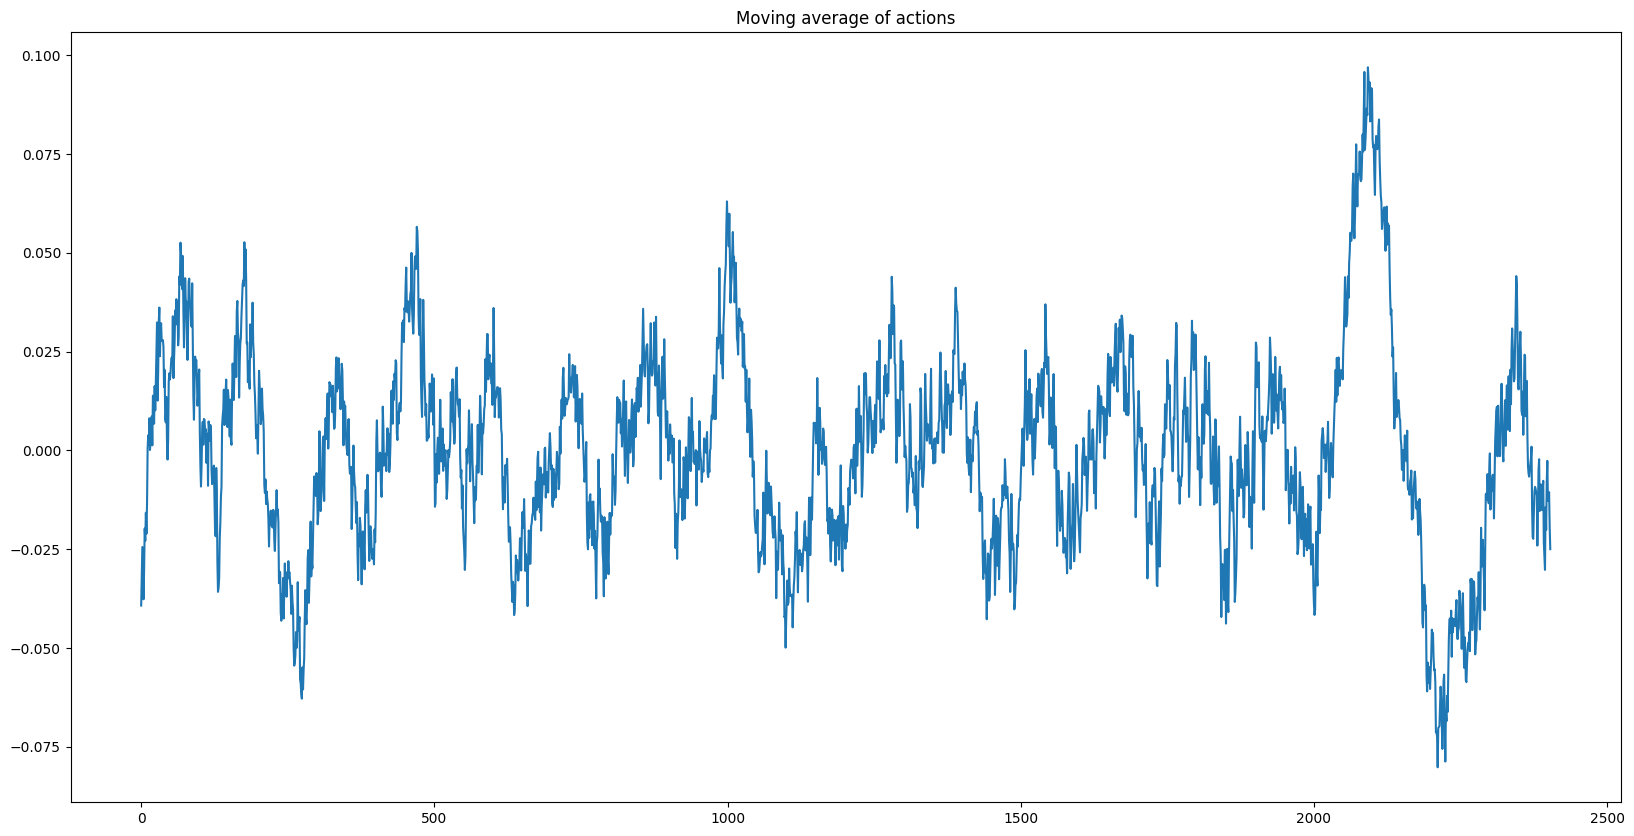

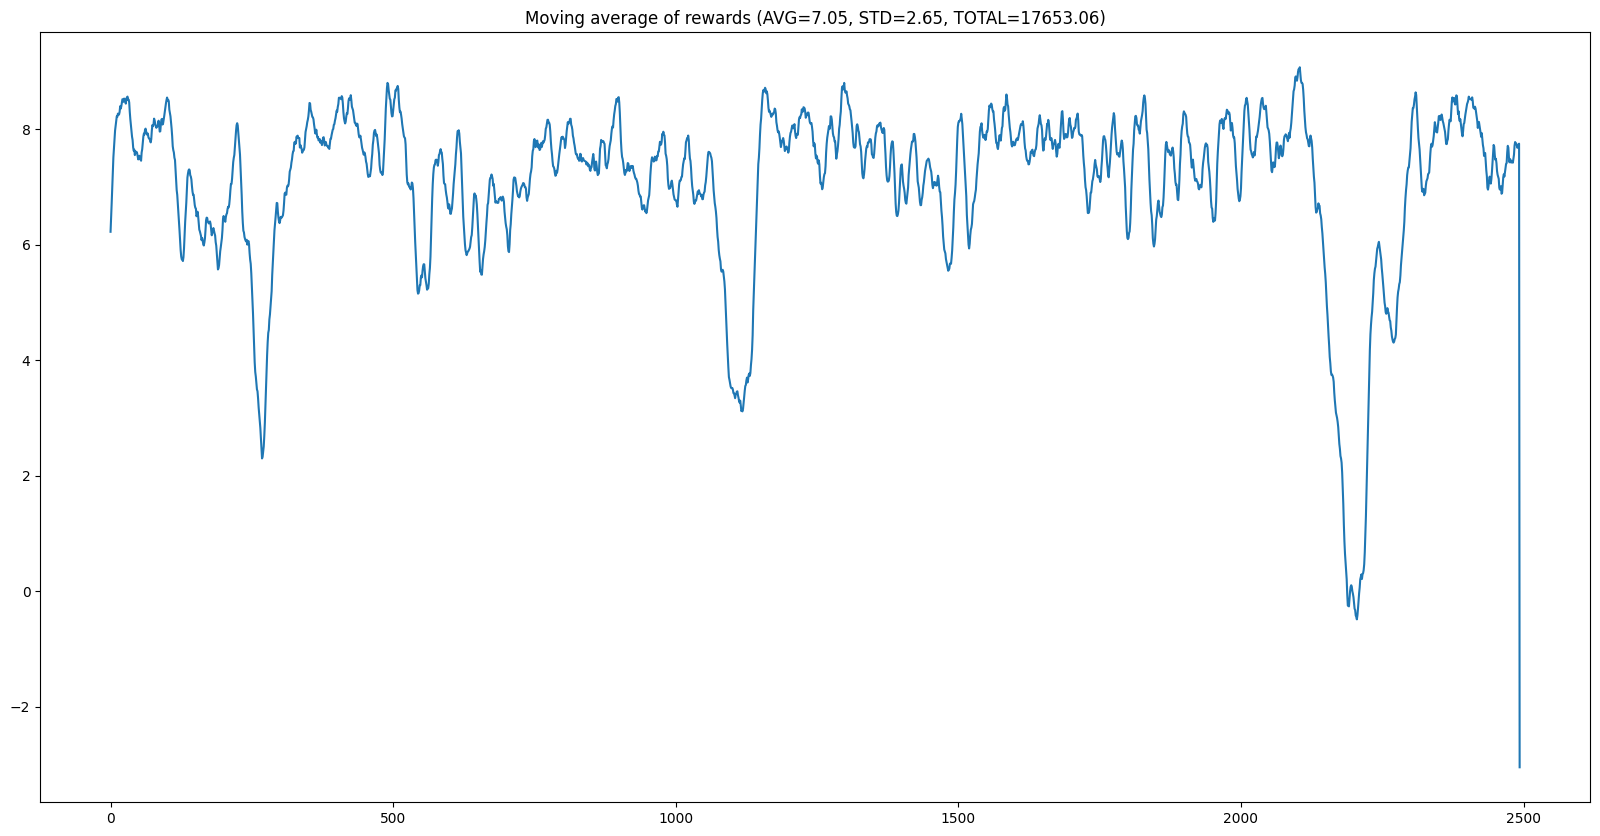

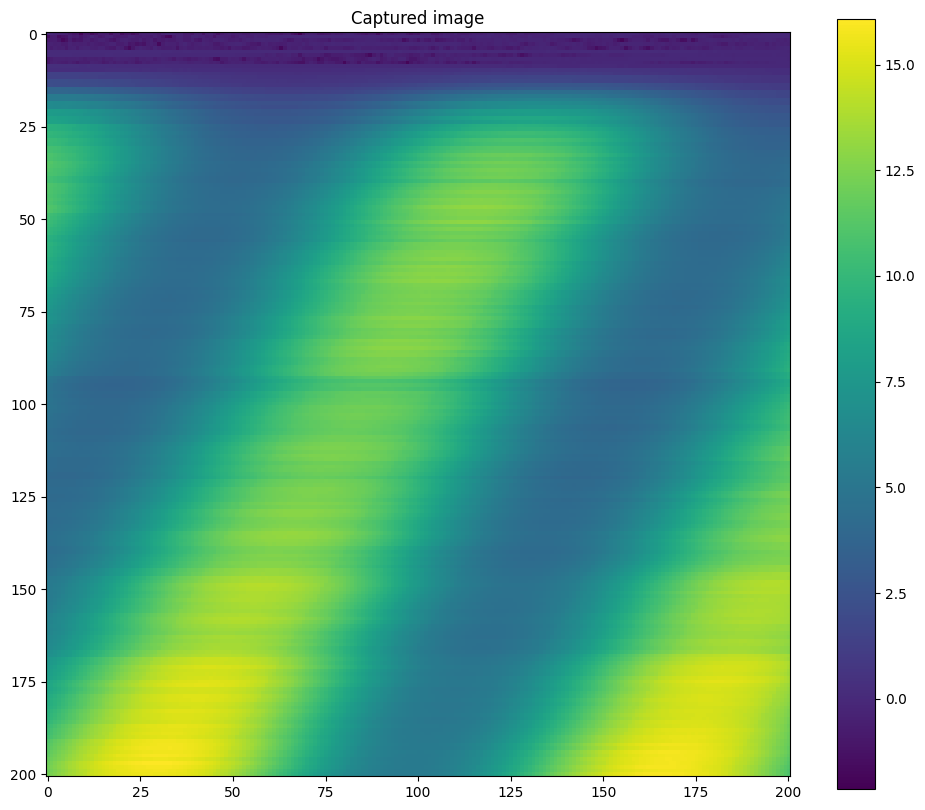

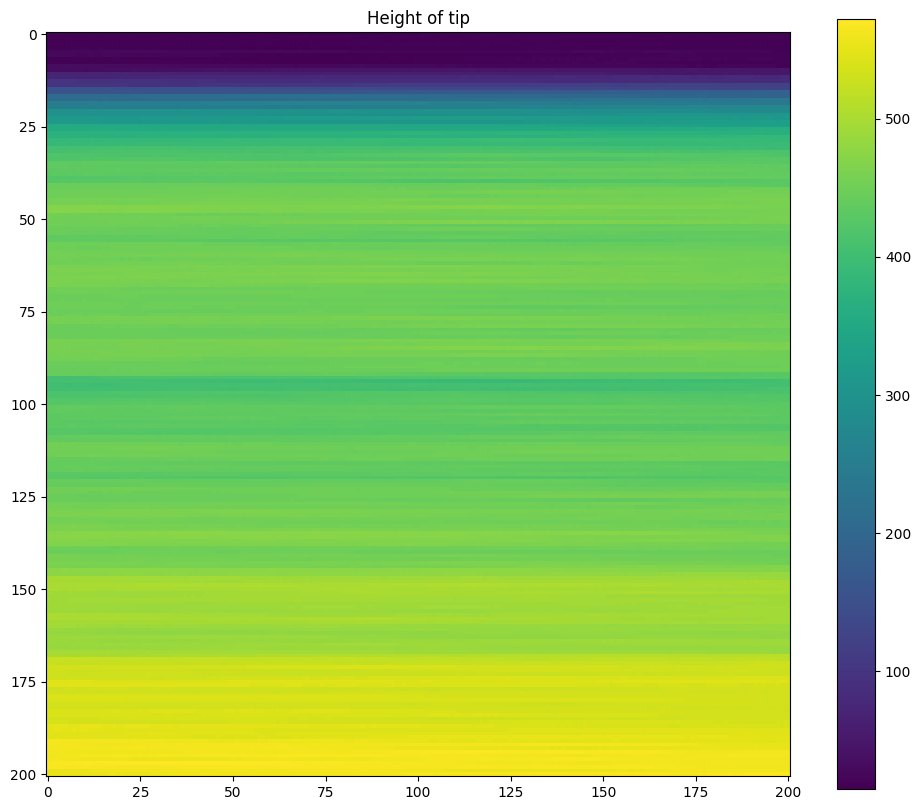

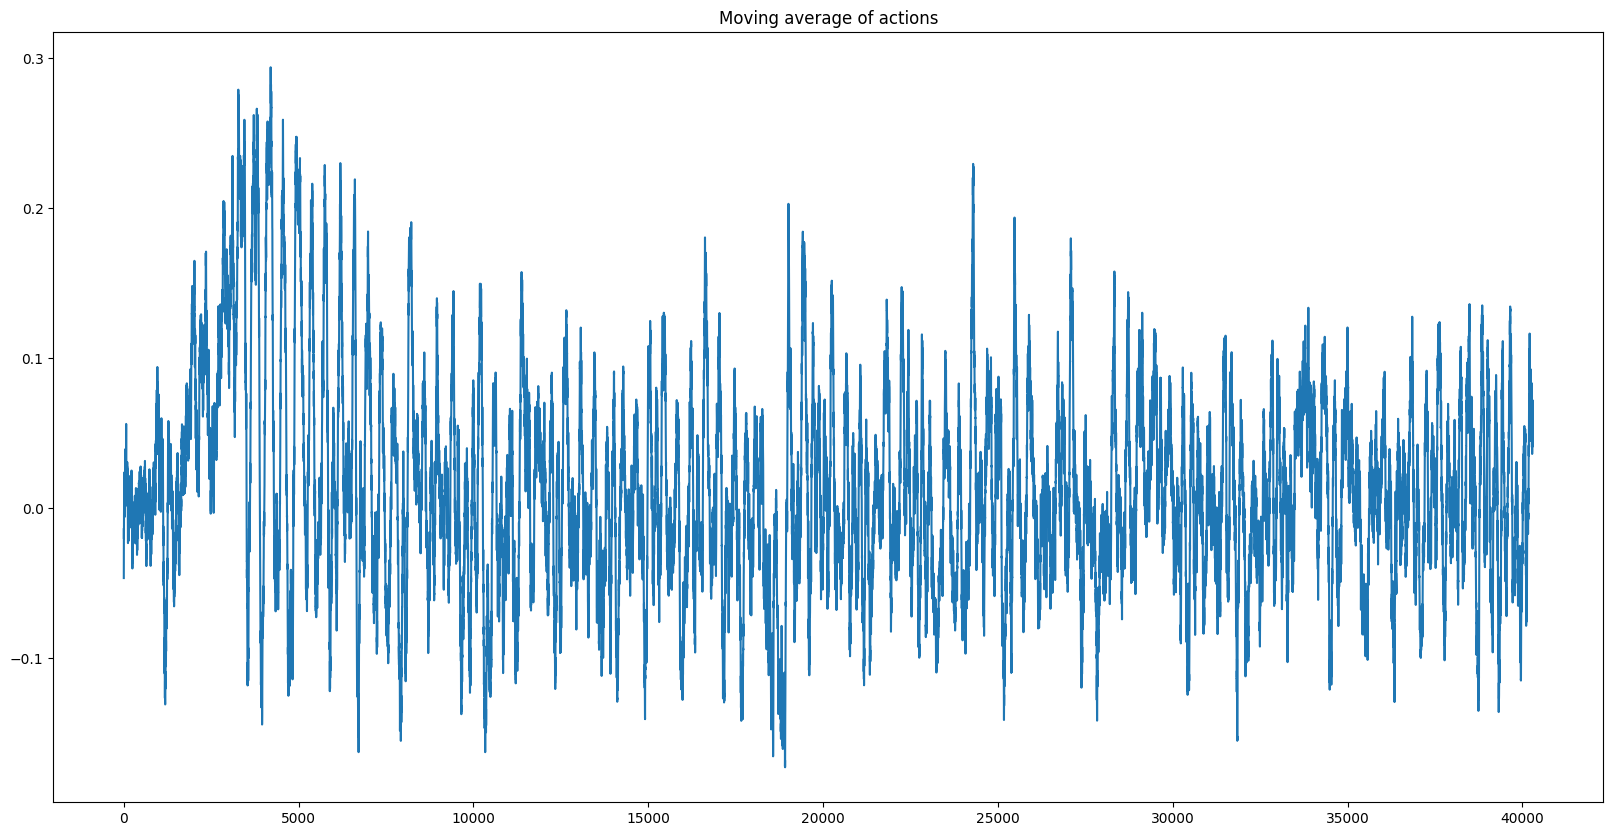

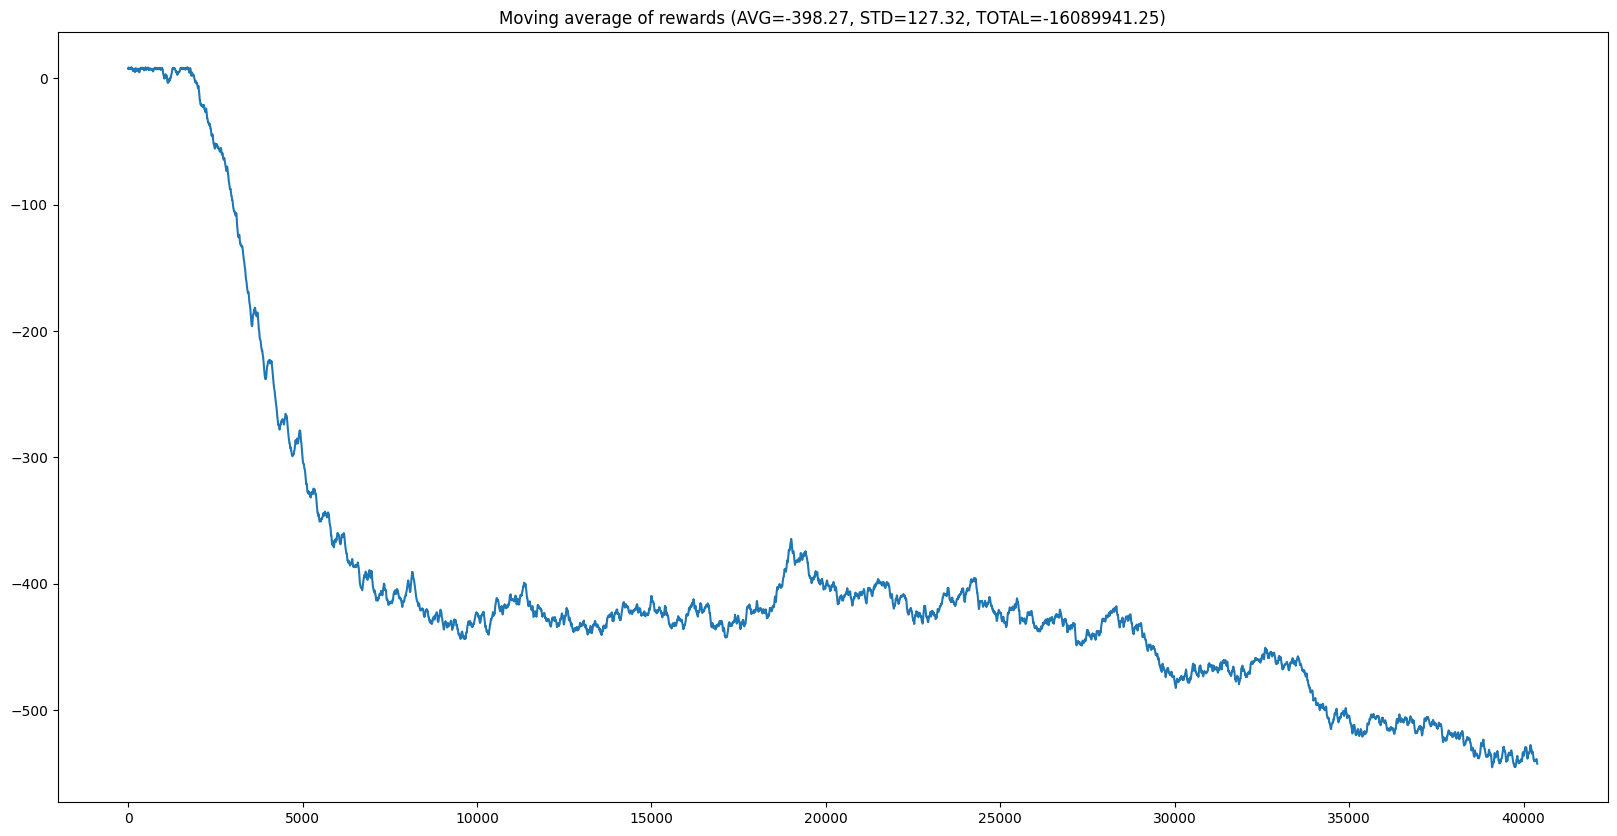

In [62]:
for ep in episode:
    evaluate_run(ep, ma_action_len=100, ma_reward_len=10)
    if not ep["terminated_early"]:
        break

In [63]:
from stable_baselines3.common.evaluation import evaluate_policy

mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=10, render=False)

/home/henry/Documents/GDrive/DocumentsCloud/Uni/TU/InterdisciplinaryProject/repo/.venv/lib/python3.11/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


KeyboardInterrupt: 